# Feature Engineering

---

1. Import packages
2. Load data
3. Feature engineering

---

## 1. Import packages

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

---
## 2. Load data

In [2]:
df = pd.read_csv('Data/clean_data_after_eda.csv')
df["date_activ"] = pd.to_datetime(df["date_activ"], format='%Y-%m-%d')
df["date_end"] = pd.to_datetime(df["date_end"], format='%Y-%m-%d')
df["date_modif_prod"] = pd.to_datetime(df["date_modif_prod"], format='%Y-%m-%d')
df["date_renewal"] = pd.to_datetime(df["date_renewal"], format='%Y-%m-%d')

In [3]:
df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000131,4.100838e-05,0.000908,2.086294,99.530517,44.235794,2.086425,9.953056e+01,44.236702,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000003,1.217891e-03,0.000000,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000,0


---

## 3. Feature engineering

### Difference between off-peak prices in December and preceding January

Below is the code created by your colleague to calculate the feature described above. Use this code to re-create this feature and then think about ways to build on this feature to create features with a higher predictive power.

In [4]:
price_df = pd.read_csv('Data/price_data.csv')
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format='%Y-%m-%d')
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [5]:
# Group off-peak prices by companies and month
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]
diff.head()

,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


Now it is time to get creative and to conduct some of your own feature engineering! Have fun with it, explore different ideas and try to create as many as you can!

## Date Based Features

### Contract Length

In [6]:
df['contract_duration'] = (df['date_end'] - df['date_activ']).dt.days
df['contract_duration'].head()

0    1096
1    2566
2    2192
3    2192
4    2245
Name: contract_duration, dtype: int64

### Days until renewal

In [ ]:
reference_date = pd.Timestamp('2016-01-01')
df['days_until_renewal'] = (df['date_renewal'] - reference_date).dt.days
df['days_until_renewal'].head()

Using a fixed reference date of 2016-01-01 (the month following the last available price data) to keep this feature meaningful for historical analysis.

## Consumption Based

### Actual vs Forecast difference

In [ ]:
forecast_diff_df = pd.DataFrame({
    'id': df['id'],
    'cons_12m_diff': df['cons_12m'] - df['forecast_cons_12m'],
    'cons_last_month_diff': df['cons_last_month'] - df['forecast_cons_year']/12
})
forecast_diff_df.head()

,id,cons_12m_diff,cons_last_month_diff
0,24011ae4ebbe3035111d65fa7c15bc57,0.00,0.000000
1,d29c2c54acc38ff3c0614d0a653813dd,4470.05,0.000000
2,764c75f661154dac3a6c254cd082ea7d,496.04,0.000000
3,bba03439a292a1e166f80264c16191cb,1343.96,0.000000
4,149d57cf92fc41cf94415803a877cb4b,3979.25,482.166667


It looks like the second comparison did not work as intended. I'll drop it from the new dataframe.

In [ ]:
forecast_diff_df = forecast_diff_df[['id', 'cons_12m_diff']]

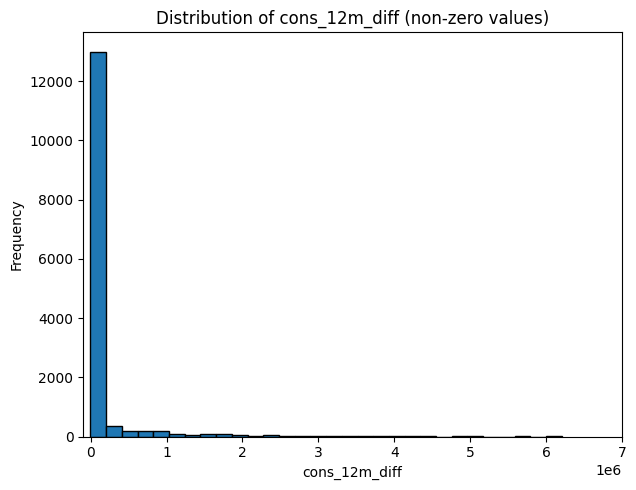

In [31]:
# Filter out zeros
cons_12m_diff_non_zero = forecast_diff_df[forecast_diff_df['cons_12m_diff'] != 0]['cons_12m_diff']

# Plot histograms

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(cons_12m_diff_non_zero, bins=30, edgecolor='k')
plt.title('Distribution of cons_12m_diff (non-zero values)')
plt.xlabel('cons_12m_diff')
plt.ylabel('Frequency')
plt.xlim(-100000, 7000000)  # Adjust x-axis limits for better visualization

plt.tight_layout()
plt.show()

Positive values mean the customer consumed more energy (kWh) than forecasted over the past 12 months. A large positive gap could indicate rapid growth or inaccurate forecasting, while negative values mean the customer used less than expected.

### Margin per product

In [34]:
df['power_cost'] = df['margin_gross_pow_ele'] - df['margin_net_pow_ele']
df['power_cost'].describe()

count    14606.000000
mean         0.002604
std          0.265157
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         31.340000
Name: power_cost, dtype: float64

The 75th percentile is 0, meaning most customers have identical gross and net power margins. This is a very sparse feature, but the non-zero values (up to 31.34) could still capture something meaningful for the subset of customers where a cost wedge exists. Keeping it in.

In [ ]:
df['net_margin_per_product'] = df['net_margin'] / df['nb_prod_act']
df['power_margin_per_product'] = df['margin_gross_pow_ele'] / df['nb_prod_act']

count    14606.000000
mean        21.641511
std         19.090709
min          0.000000
25%         10.752500
50%         18.790000
75%         27.320000
max        314.760000
Name: power_margin_per_product, dtype: float64

---

## Combining Features

Merge all engineered features into the main dataframe.

In [ ]:
# Merge price difference features (from colleague's example)
df = df.merge(diff, on='id', how='left')

# Merge consumption difference features
df = df.merge(forecast_diff_df[['id', 'cons_12m_diff']], on='id', how='left')

print(df.shape)
df.head(3)